# Global Cancer Prediction Project

Proyek yang digunakan kali ini adalah **Prediksi Penyakit Kanker**. Proyek ini bertujuan untuk memprediksi apakah seseorang berisiko terkena kanker berdasarkan data medis dan karakteristik demografis tertentu. Dengan menggunakan model machine learning, proyek ini mencoba mengidentifikasi pola dari data historis untuk memberikan prediksi yang akurat, yang pada akhirnya dapat membantu dalam deteksi dini penyakit kanker.

Dataset yang digunakan adalah: [Global Cancer Patients 2015-2024](https://www.kaggle.com/datasets/zahidmughal2343/global-cancer-patients-2015-2024).


# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# Load Datasets

In [3]:
from google.colab import files
files.upload()  # upload kaggle.json dari komputer kamu

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muazahaladawiyah","key":"11358aa7840b6b7a3258400da44049d4"}'}

In [4]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)  # agar tidak error permission

In [5]:
!kaggle datasets download -d zahidmughal2343/global-cancer-patients-2015-2024

Dataset URL: https://www.kaggle.com/datasets/zahidmughal2343/global-cancer-patients-2015-2024
License(s): CC-BY-NC-SA-4.0
global-cancer-patients-2015-2024.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
import zipfile

with zipfile.ZipFile("global-cancer-patients-2015-2024.zip", "r") as zip_ref:
    zip_ref.extractall("global-cancer-patients-2015-2024")

In [7]:
df = pd.read_csv("global-cancer-patients-2015-2024/global_cancer_patients_2015_2024.csv")
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [8]:
print(" Informasi Dataset:")
df.info()

 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-n

In [9]:
print(" Nama Kolom:")
print(df.columns.tolist())

 Nama Kolom:
['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years', 'Target_Severity_Score']


In [10]:
print(" Missing Value:")
print(df.isnull().sum())

 Missing Value:
Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64


In [11]:
# Hapus kolom id
df = df.drop(columns=['Patient_ID'], errors='ignore')

In [12]:
print(" Jumlah Data Duplikat:")
print(df.duplicated().sum())

 Jumlah Data Duplikat:
0


In [13]:
# Menghapus duplikat
df = df.drop_duplicates()

# Cek ulang jumlah data
print("Jumlah data setelah duplikat dihapus:", df.shape)

Jumlah data setelah duplikat dihapus: (50000, 14)


In [14]:
print(" Statistik Deskriptif:")
display(df.describe())

 Statistik Deskriptif:


,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


# Exploratory Data Analysis

Data yang dianalisis yakni: <br>
1. Kota mana yang memiliki jumlah penderita kanker terbanyak? <br>
2. Rentang usia apa yang sering terjangkit kanker? <br>
3. Tipe kanker apa yang paling sering ditemukan di antara penderita? <br>


In [15]:
print(" Informasi Dataset:")
df.info()

 Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Country_Region         50000 non-null  object 
 3   Year                   50000 non-null  int64  
 4   Genetic_Risk           50000 non-null  float64
 5   Air_Pollution          50000 non-null  float64
 6   Alcohol_Use            50000 non-null  float64
 7   Smoking                50000 non-null  float64
 8   Obesity_Level          50000 non-null  float64
 9   Cancer_Type            50000 non-null  object 
 10  Cancer_Stage           50000 non-null  object 
 11  Treatment_Cost_USD     50000 non-null  float64
 12  Survival_Years         50000 non-null  float64
 13  Target_Severity_Score  50000 non-null  float64
dtypes: float64(8), int64(2), object(4)

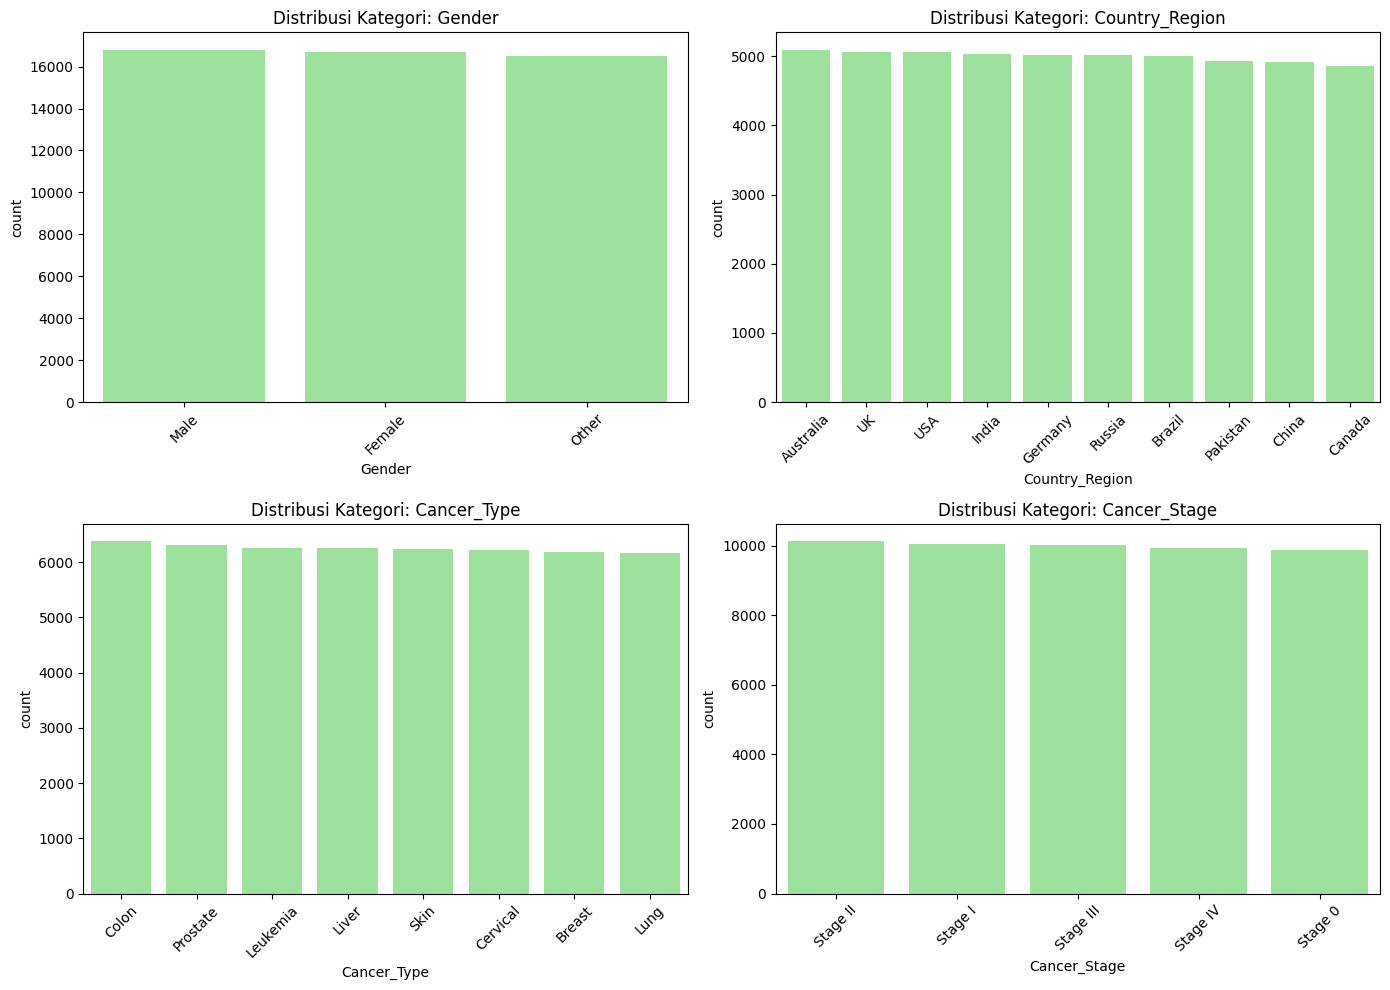

In [16]:
# semua kolom kategorikal
kategori = df.select_dtypes(include='object')

# layout
n_cols = 2
n_rows = 2
plots_per_page = n_cols * n_rows

# Loop per 4 fitur
for i in range(0, len(kategori.columns), plots_per_page):
    sub_cols = kategori.columns[i:i + plots_per_page]
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
    axes = axes.flatten()

    for j, col in enumerate(sub_cols):
        sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axes[j], color='lightgreen')
        axes[j].set_title(f'Distribusi Kategori: {col}')
        axes[j].tick_params(axis='x', rotation=45)

    # Hapus plot kosong jika fitur kurang dari 4
    for k in range(j + 1, plots_per_page):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

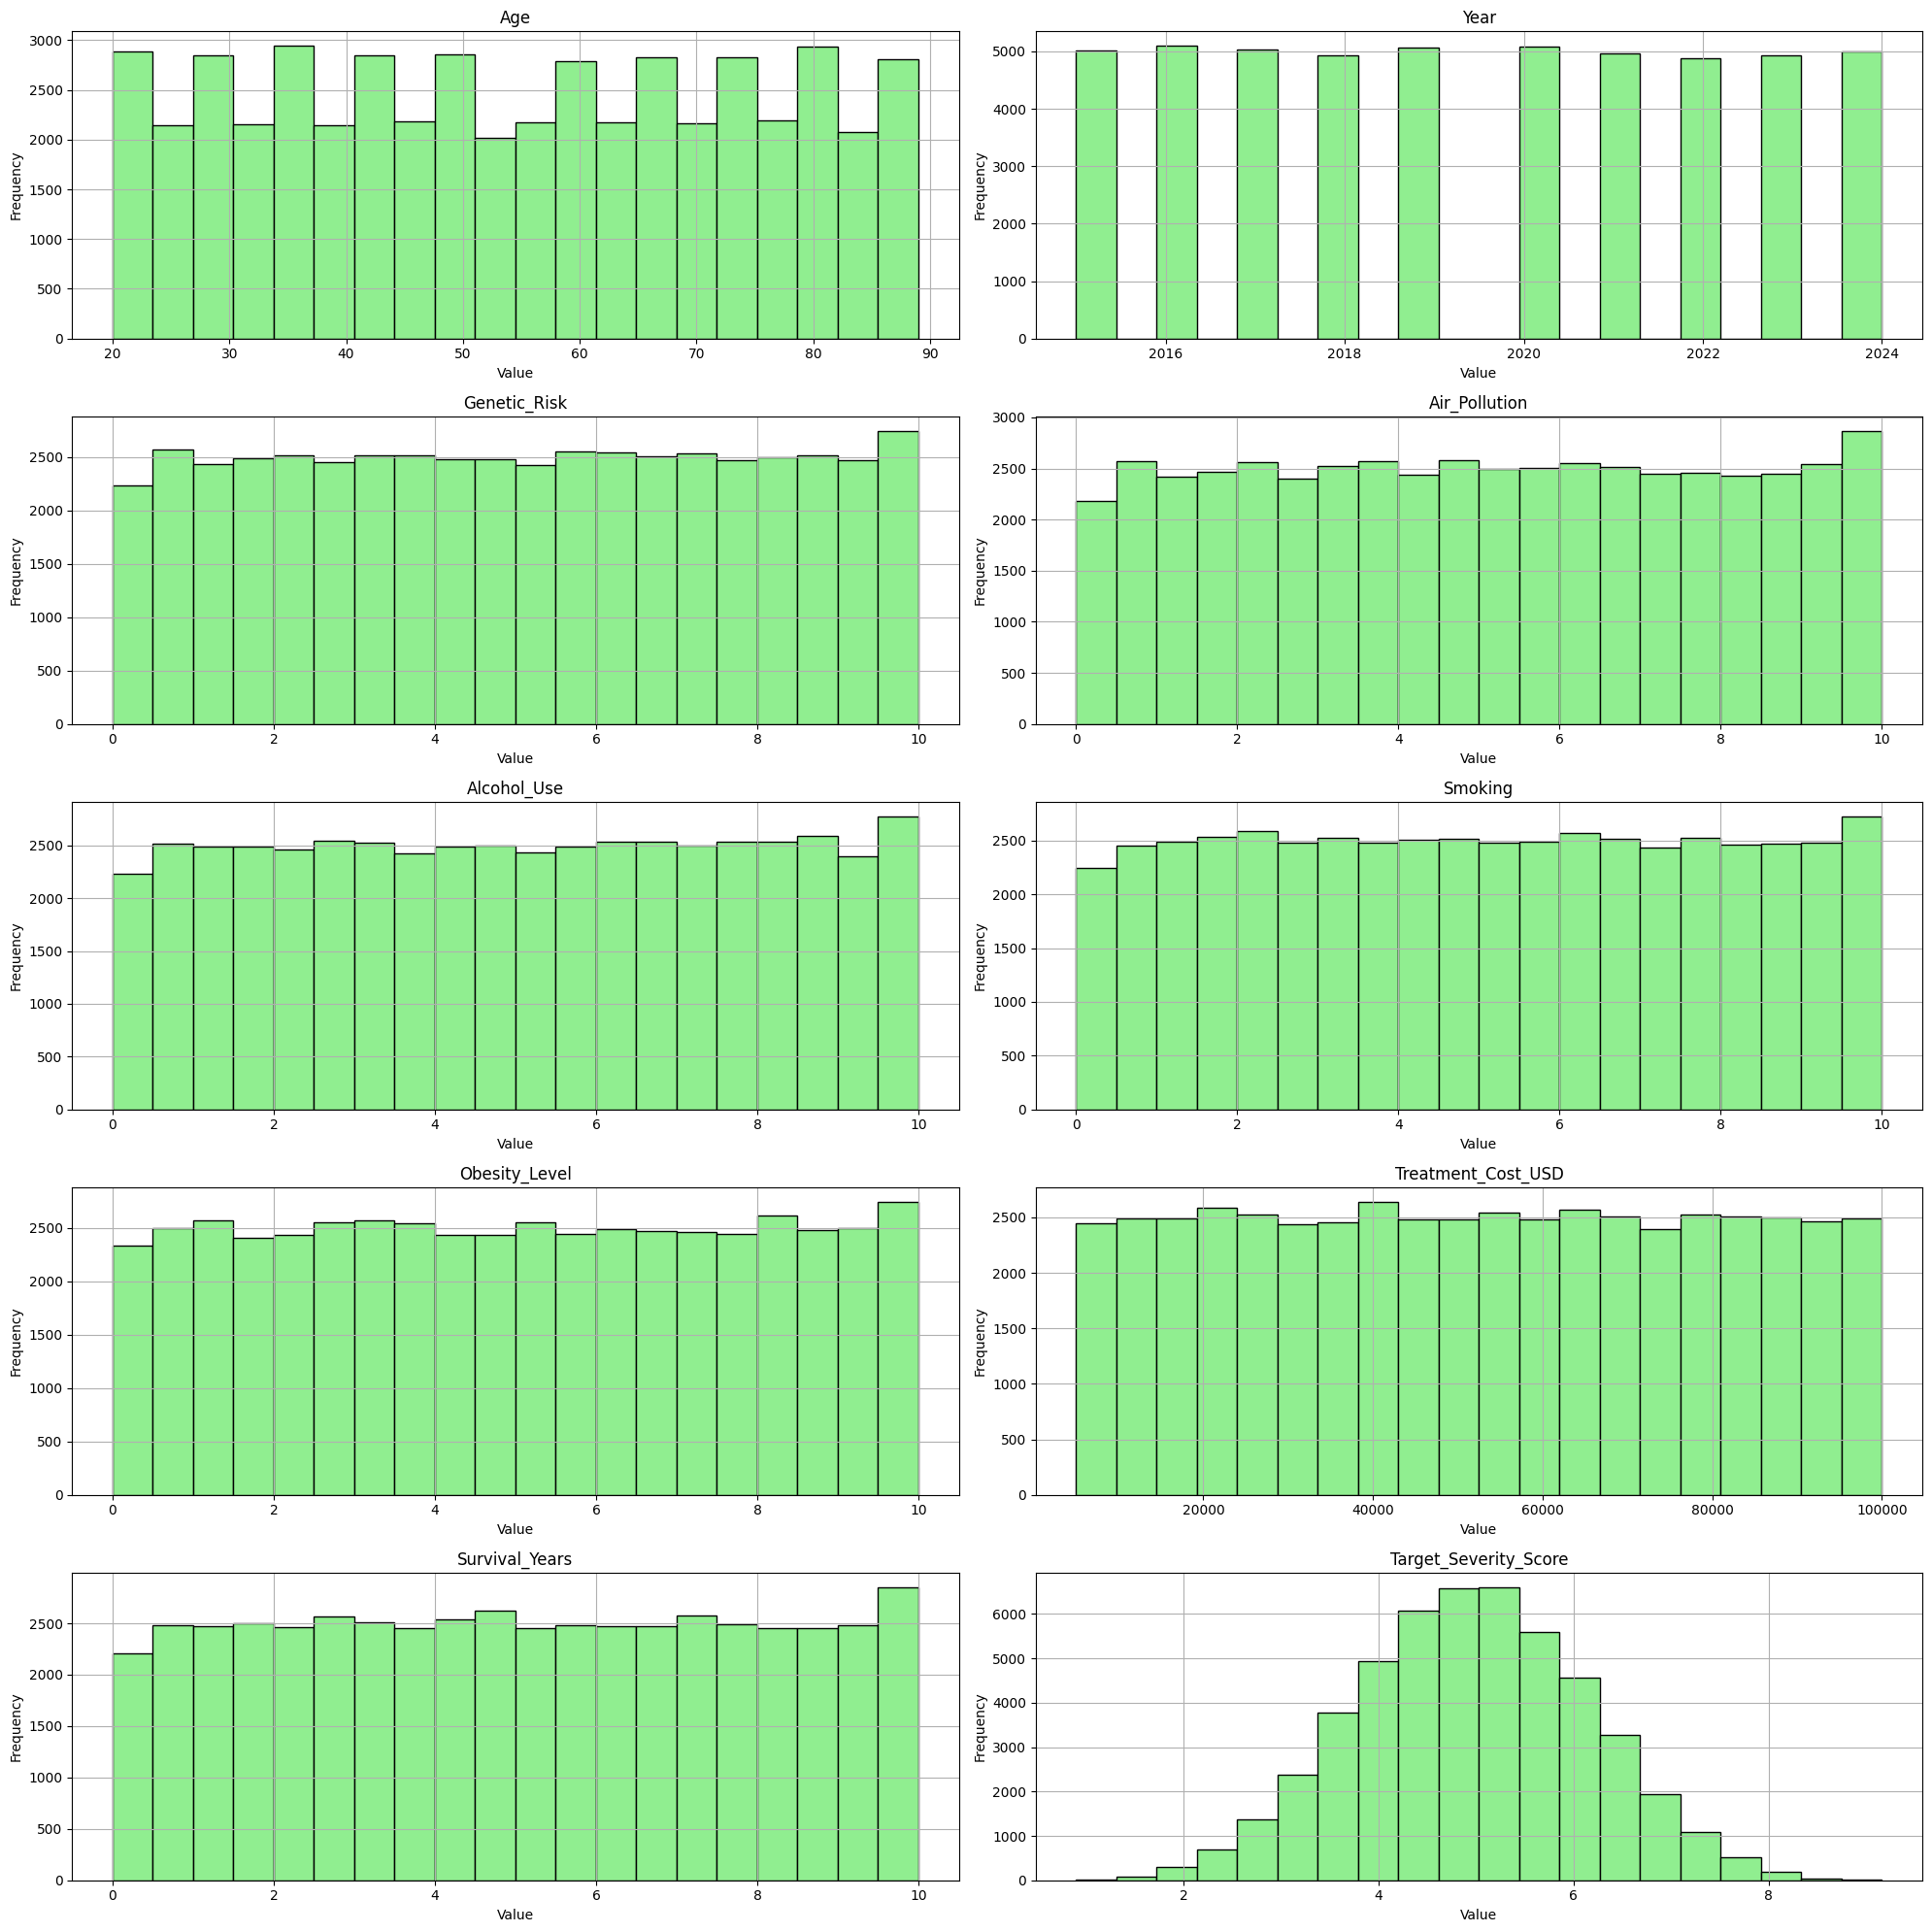

In [17]:
num_vars = df.select_dtypes(include='number').columns
n_cols = 2
n_rows = -(-len(num_vars) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, column in enumerate(num_vars):
    df[column].hist(ax=axes[i], bins=20, edgecolor='black', color='lightgreen')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

--- Cek Outlier dengan Boxplot ---


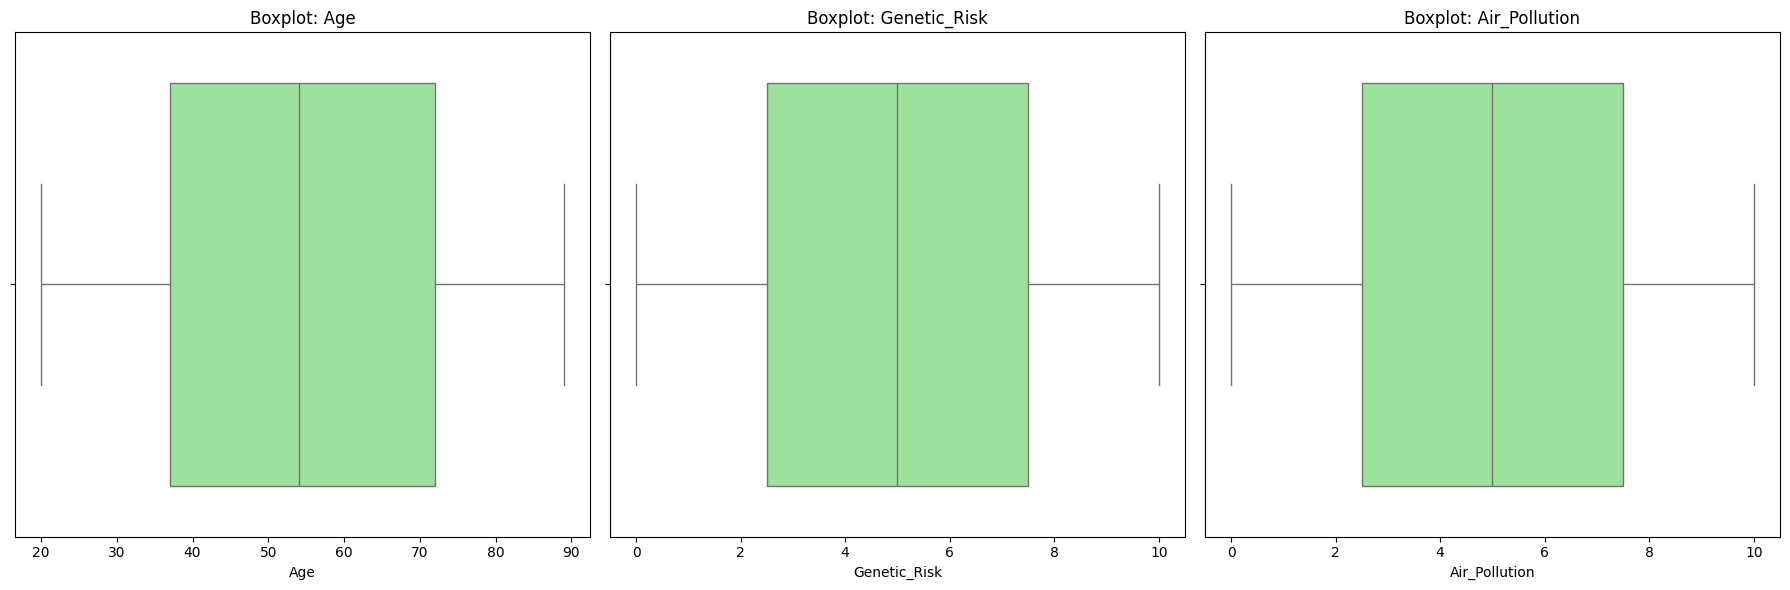

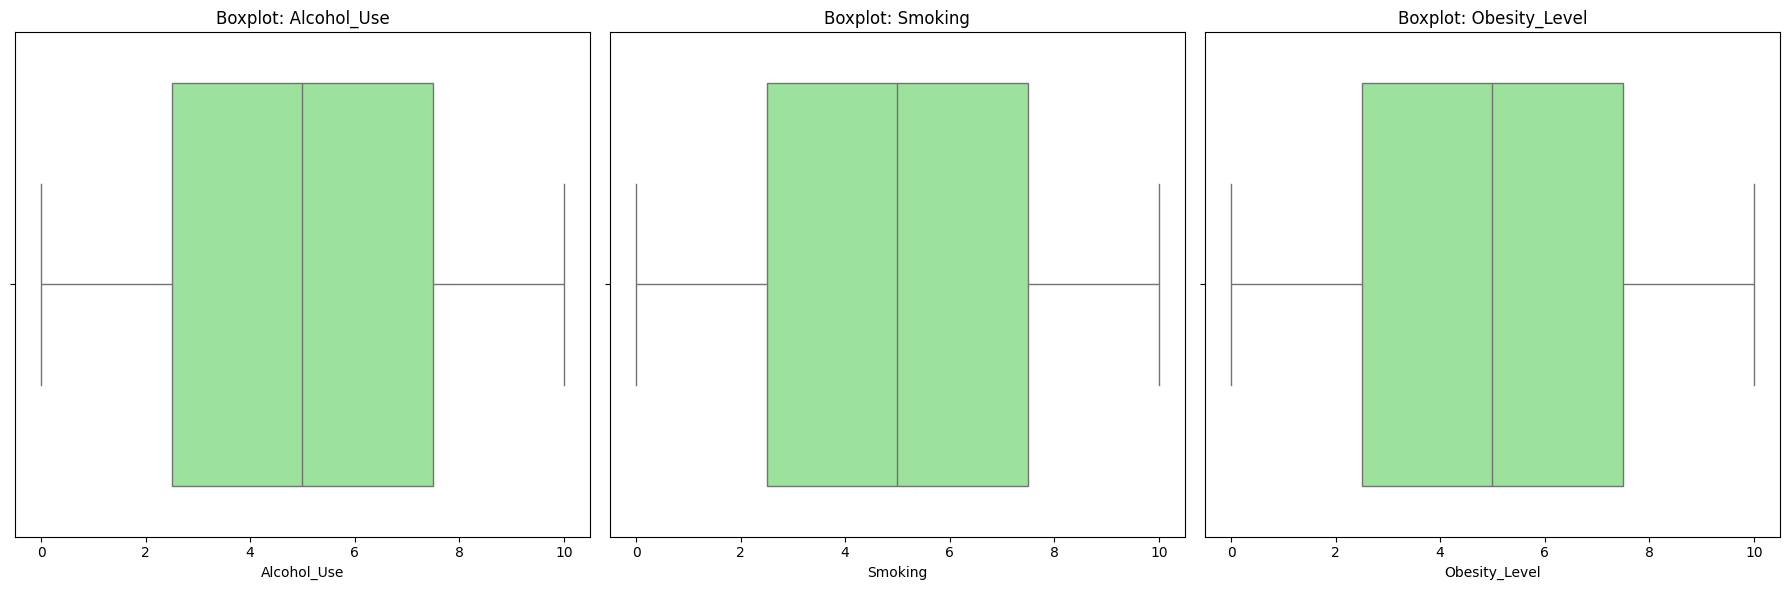

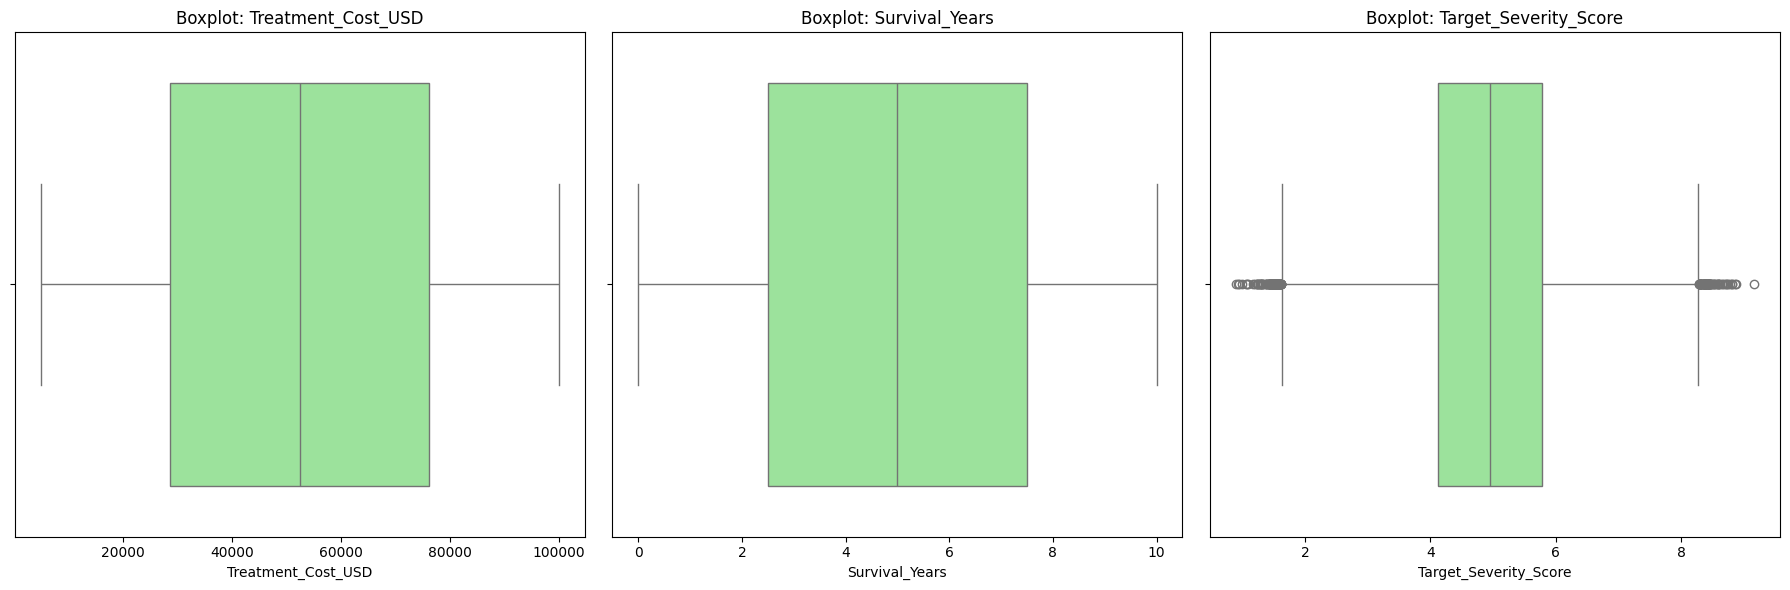

In [18]:
# Boxplot untuk Deteksi Outlier ---
print('--- Cek Outlier dengan Boxplot ---')
cols_numerik = [
    'Age', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use',
    'Smoking', 'Obesity_Level', 'Treatment_Cost_USD',
    'Survival_Years', 'Target_Severity_Score'
]

cols_per_row = 3
num_cols = len(cols_numerik)

for i in range(0, num_cols, cols_per_row):
    sub_cols = cols_numerik[i:i+cols_per_row]
    fig, axes = plt.subplots(1, len(sub_cols), figsize=(18, 6))

    if len(sub_cols) == 1:
        axes = [axes]

    for j, feature in enumerate(sub_cols):
        sns.boxplot(x=df[feature], ax=axes[j], color='lightgreen')
        axes[j].set_title(f'Boxplot: {feature}')

    plt.tight_layout()
    plt.show()

Cek Distribusi Data


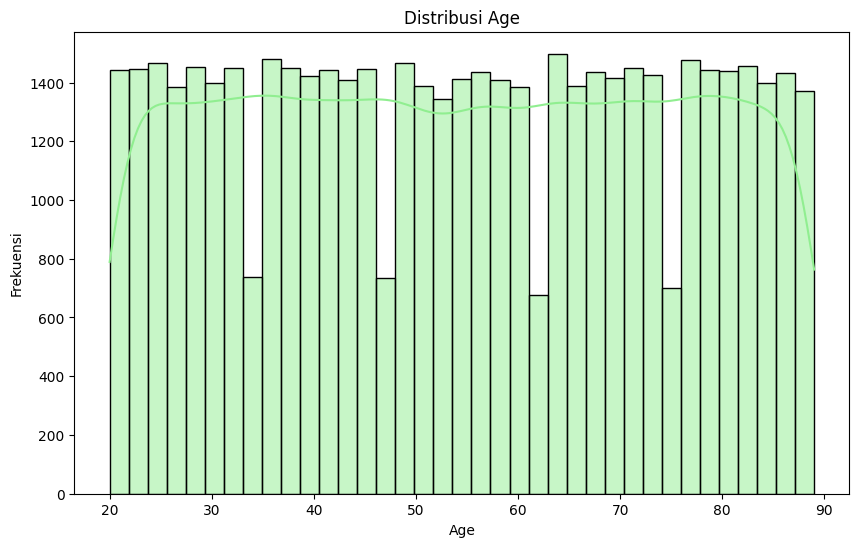

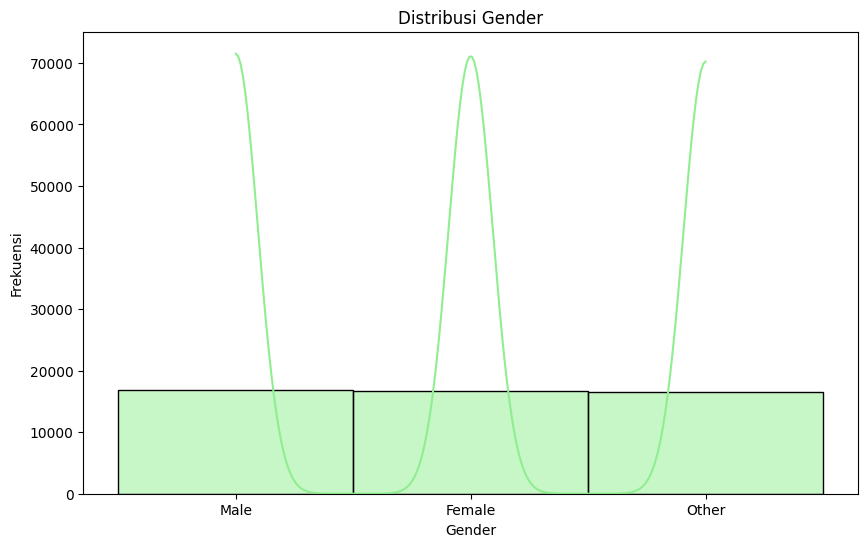

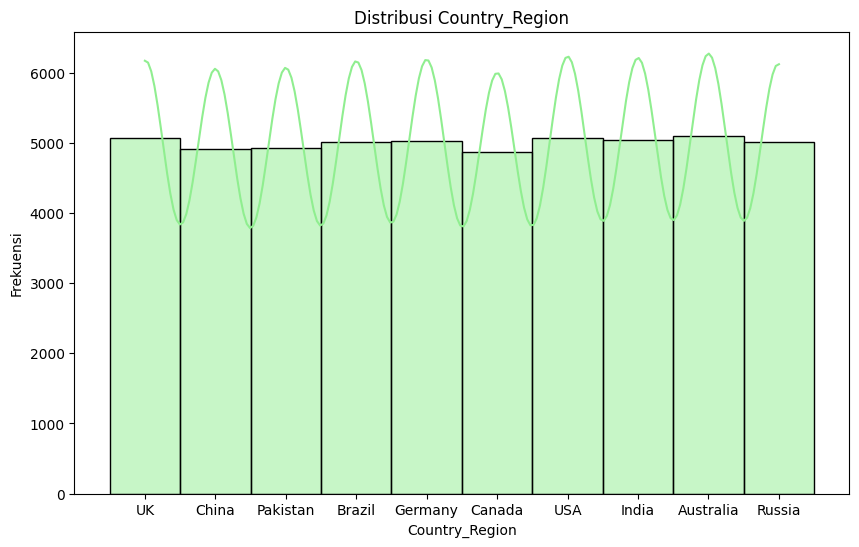

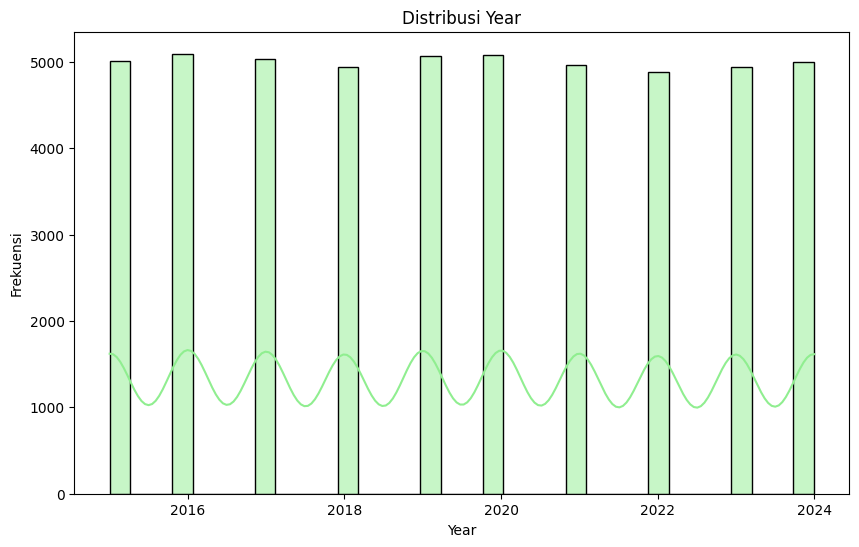

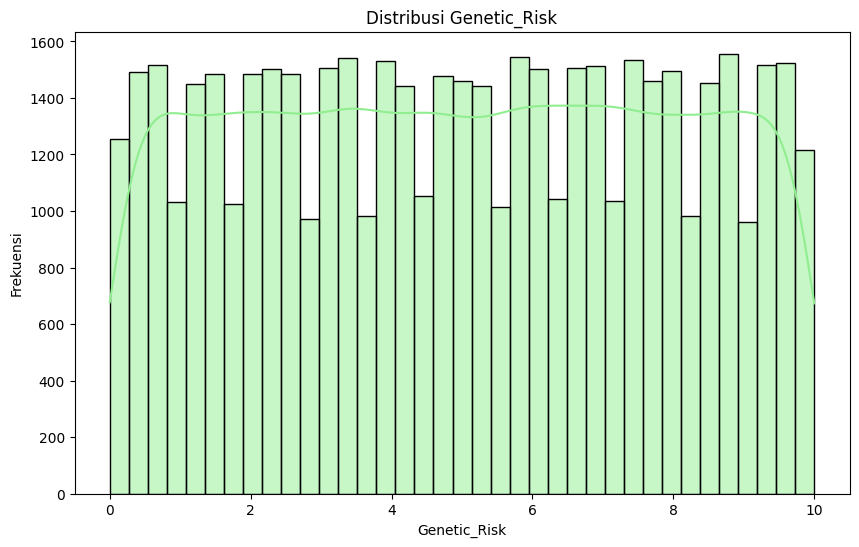

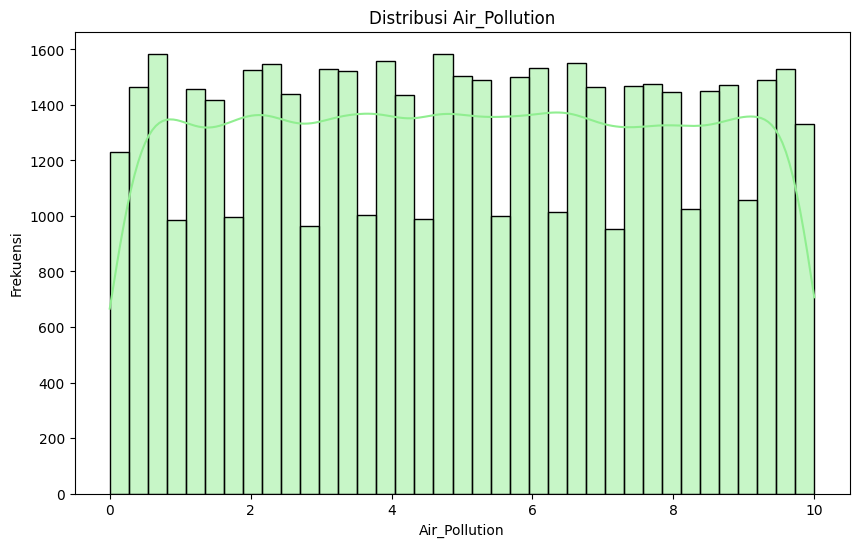

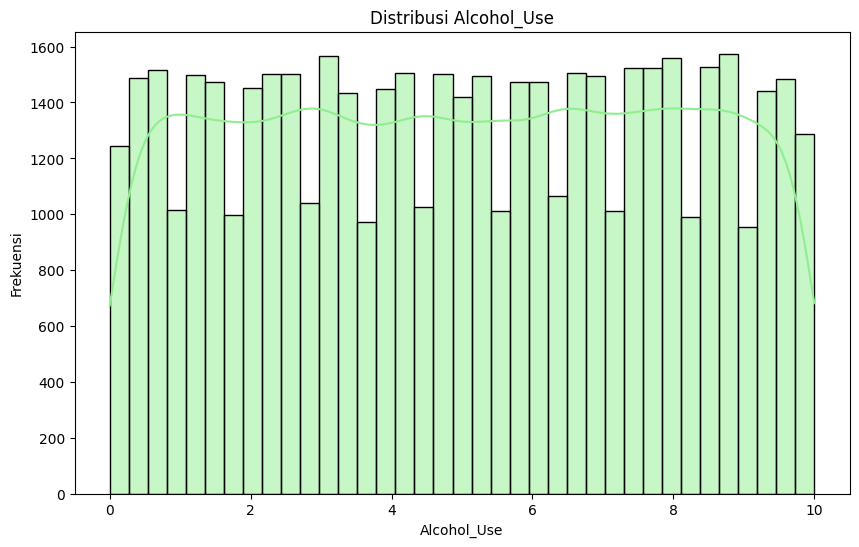

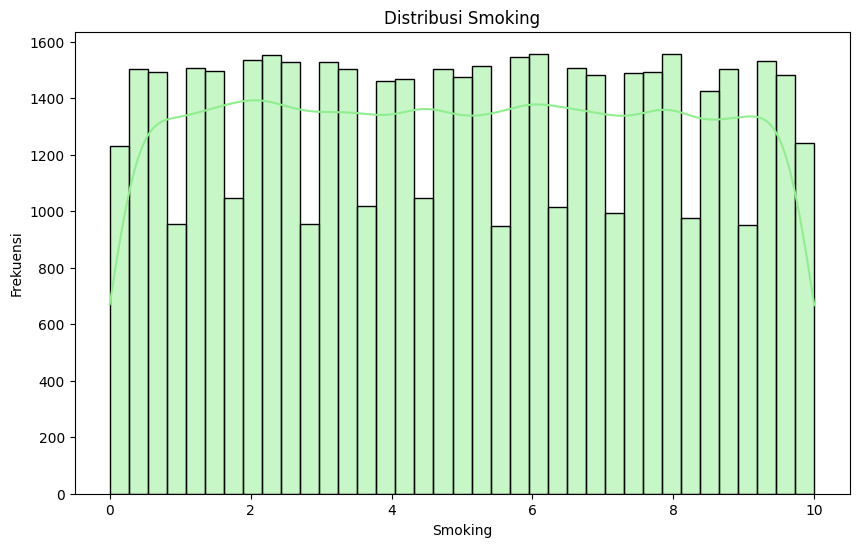

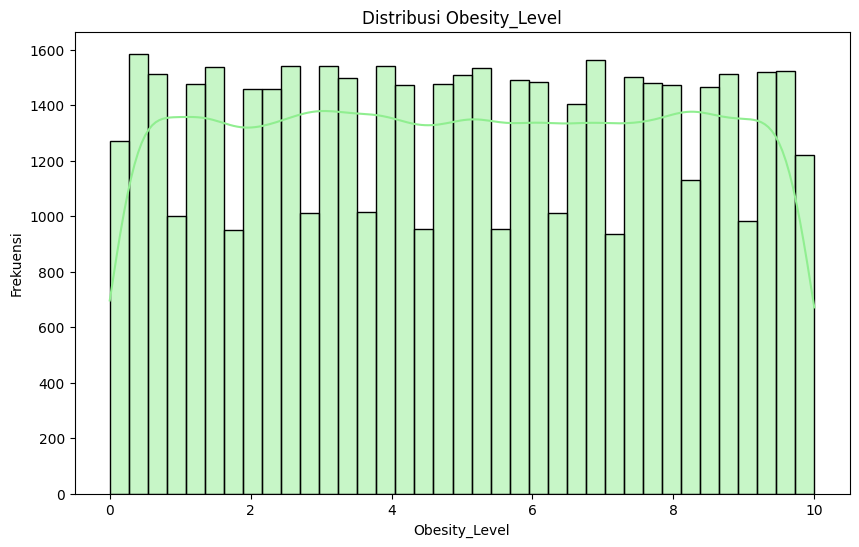

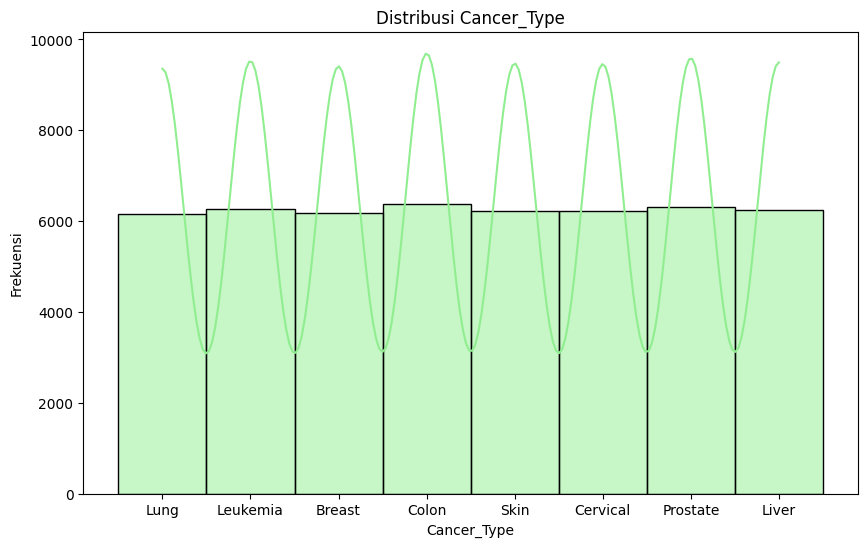

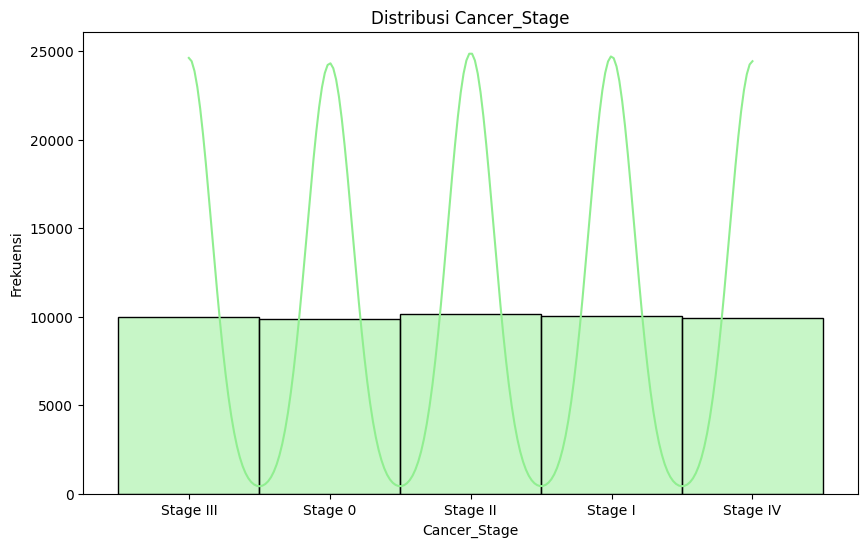

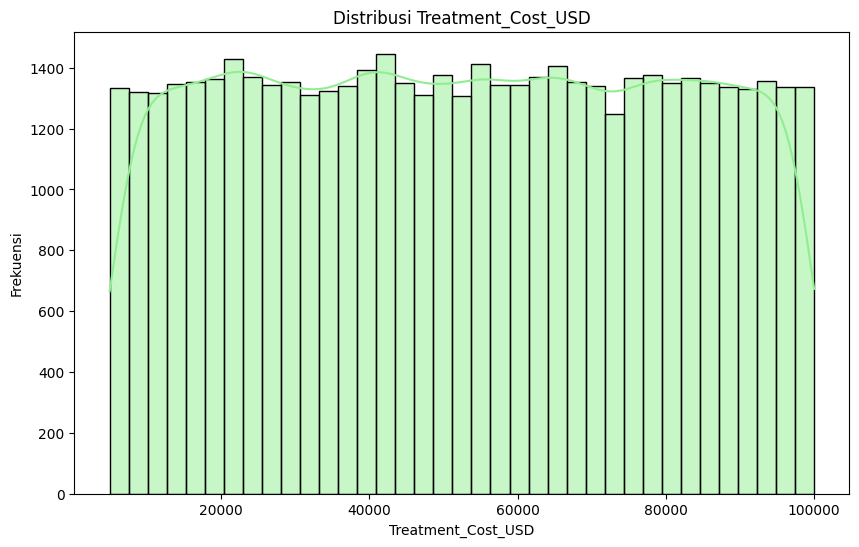

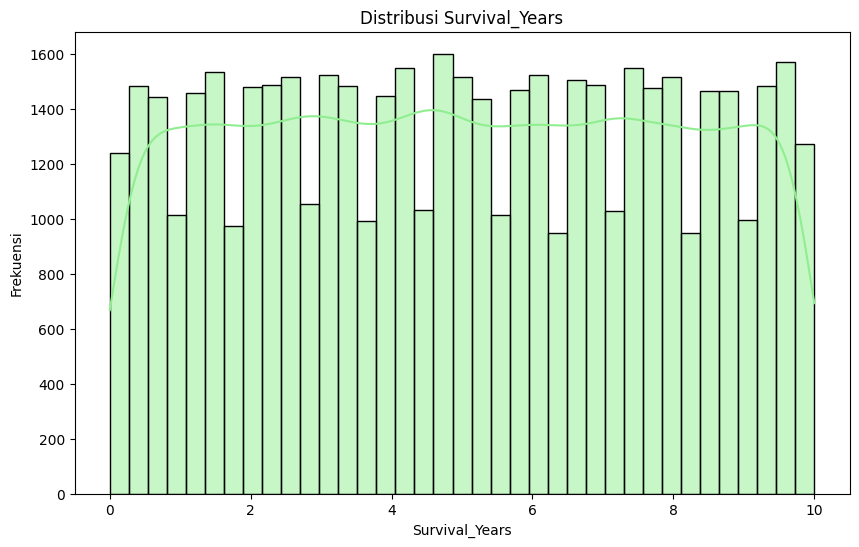

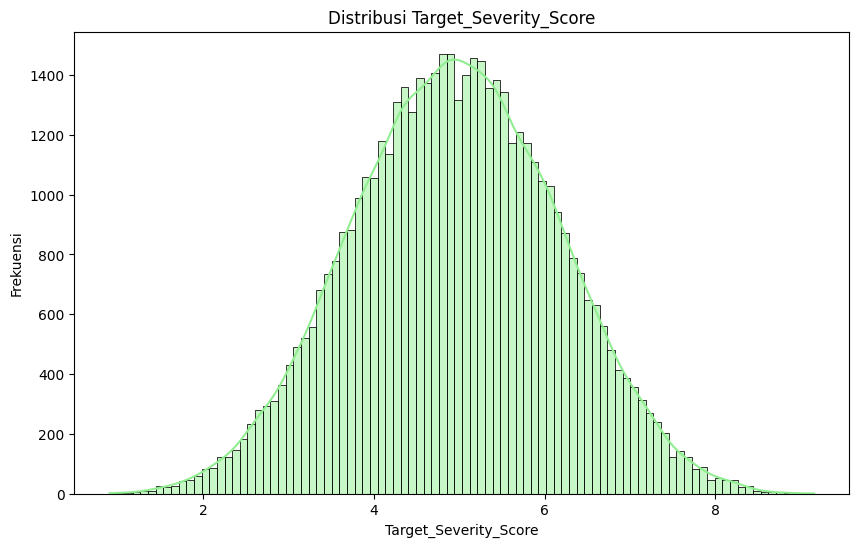

In [19]:
# cek distribusi data
print('Cek Distribusi Data')
for feature in df.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(df[feature], color='lightgreen', kde=True)
    plt.title(f'Distribusi {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frekuensi')
    plt.show()

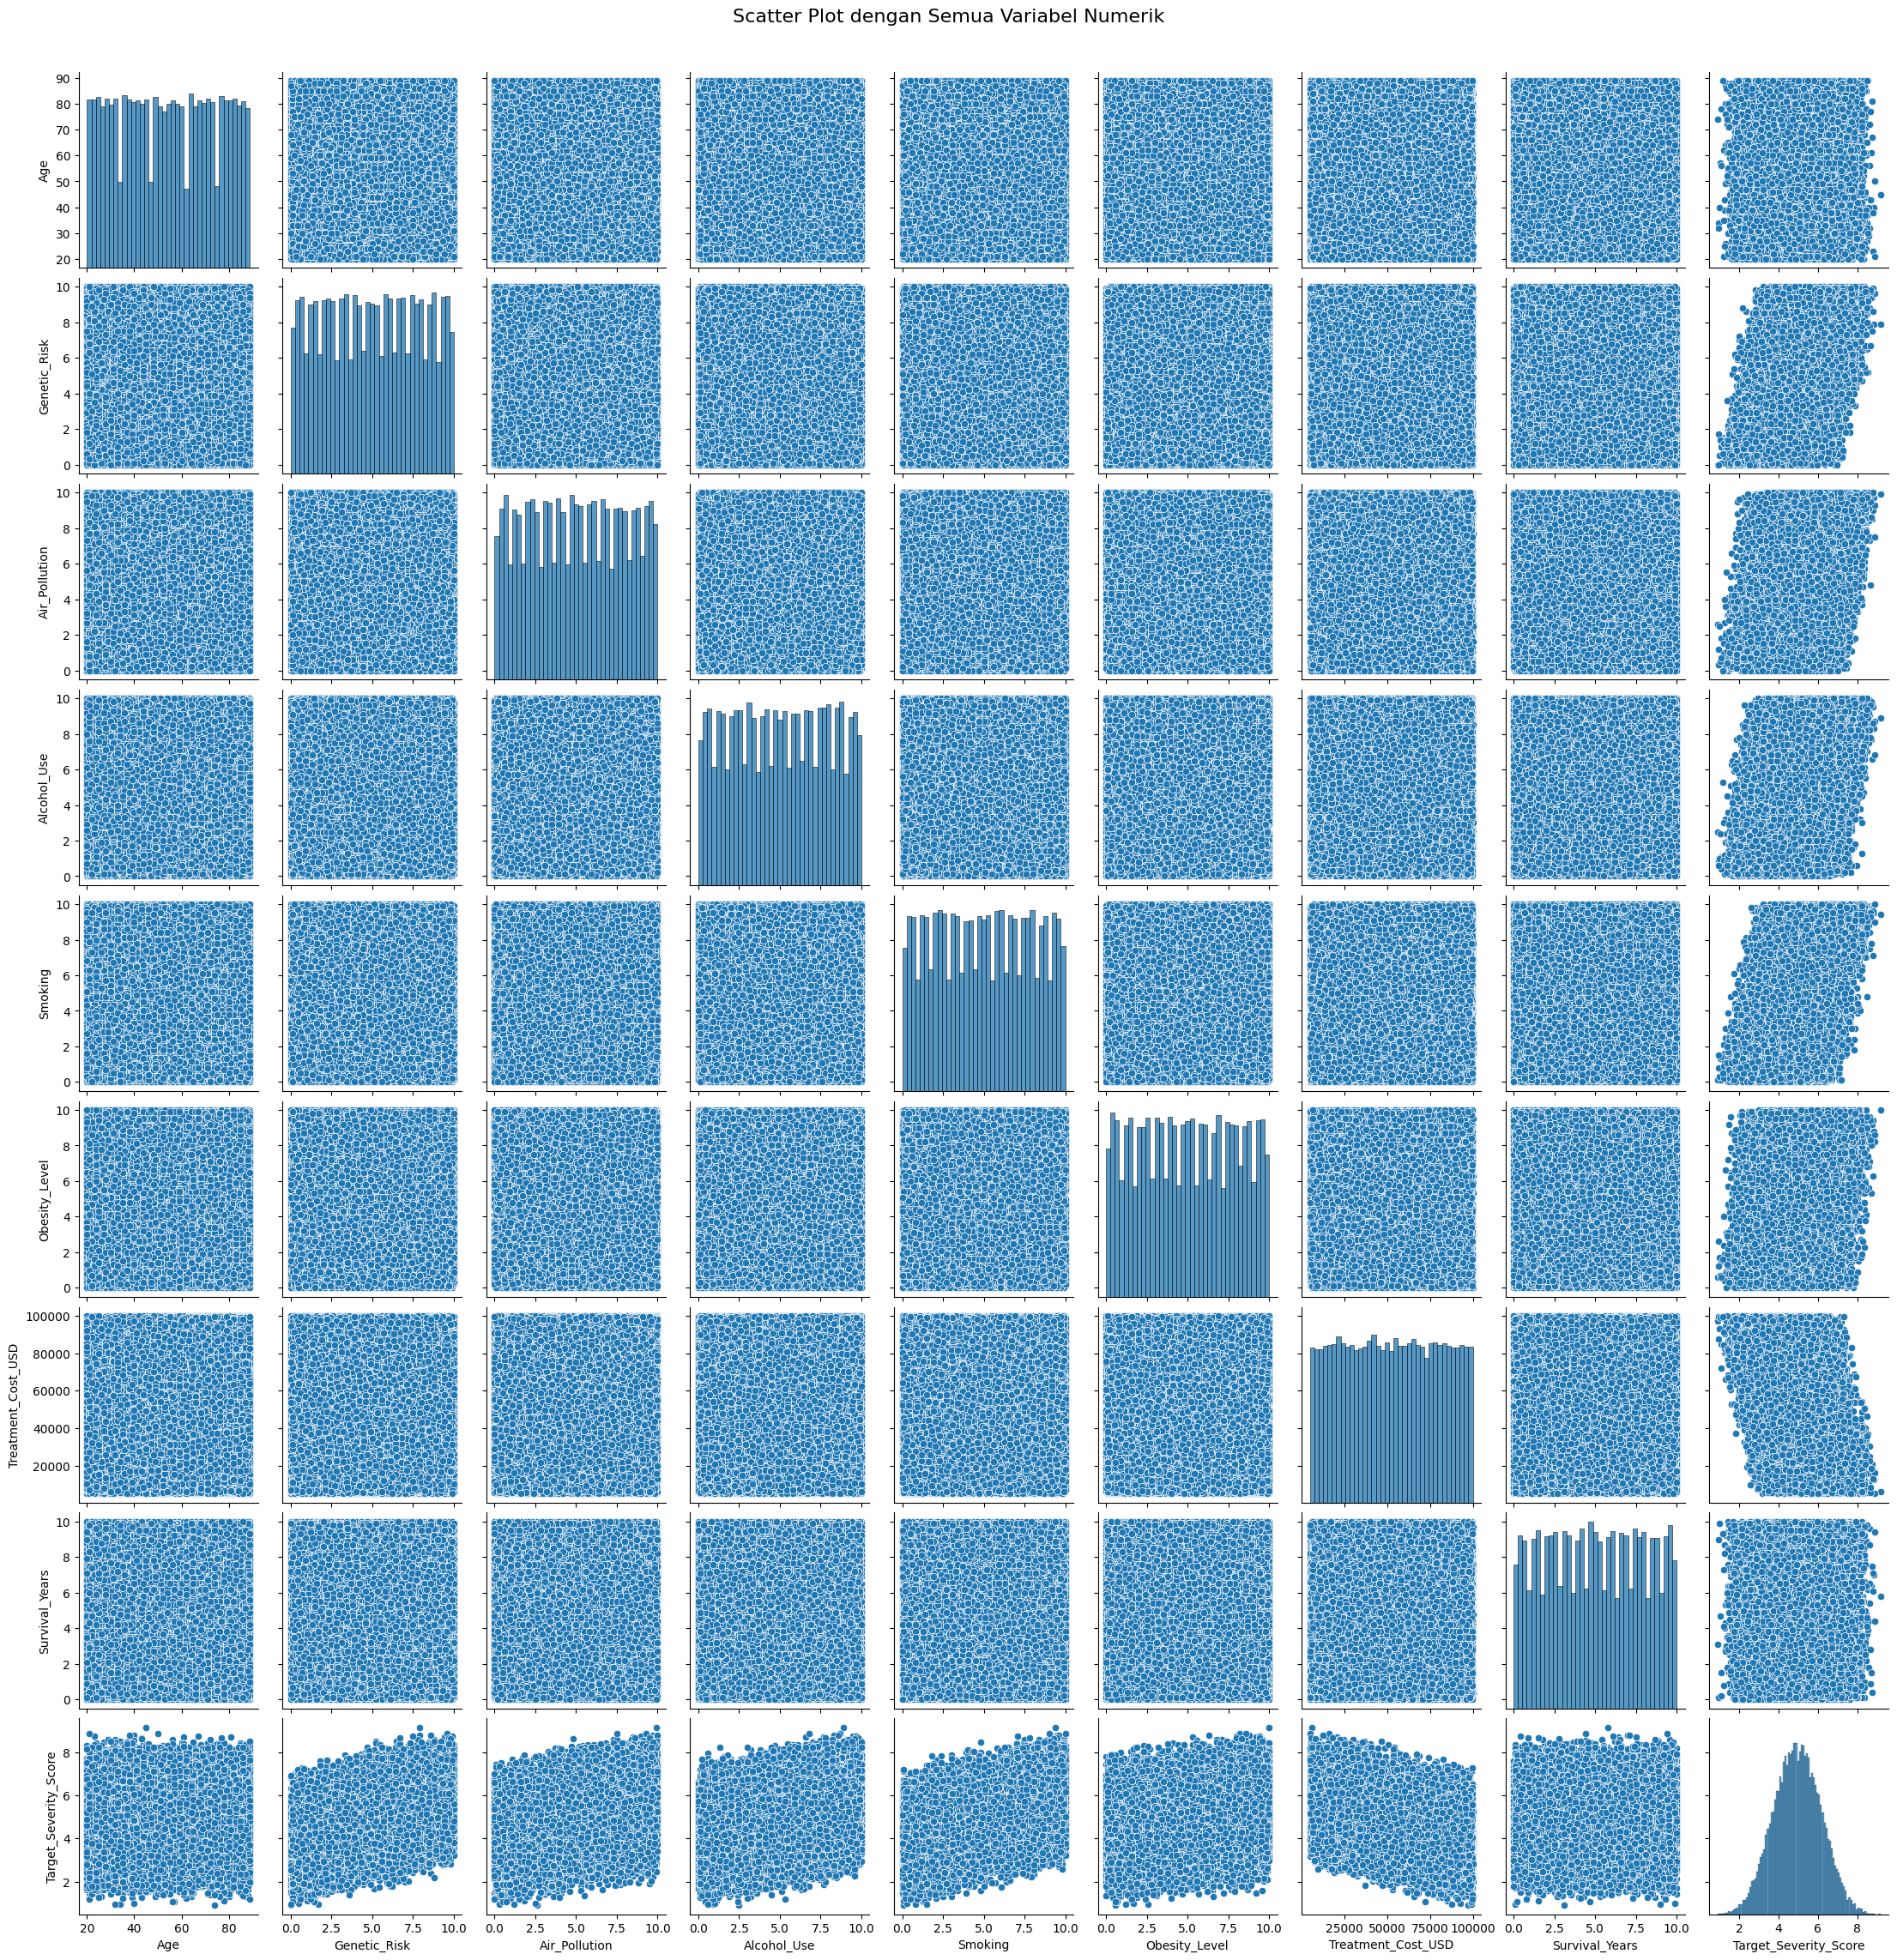

In [20]:
sns.pairplot(df[cols_numerik])
plt.suptitle('Scatter Plot dengan Semua Variabel Numerik', fontsize=16, y=1.02)
plt.show()

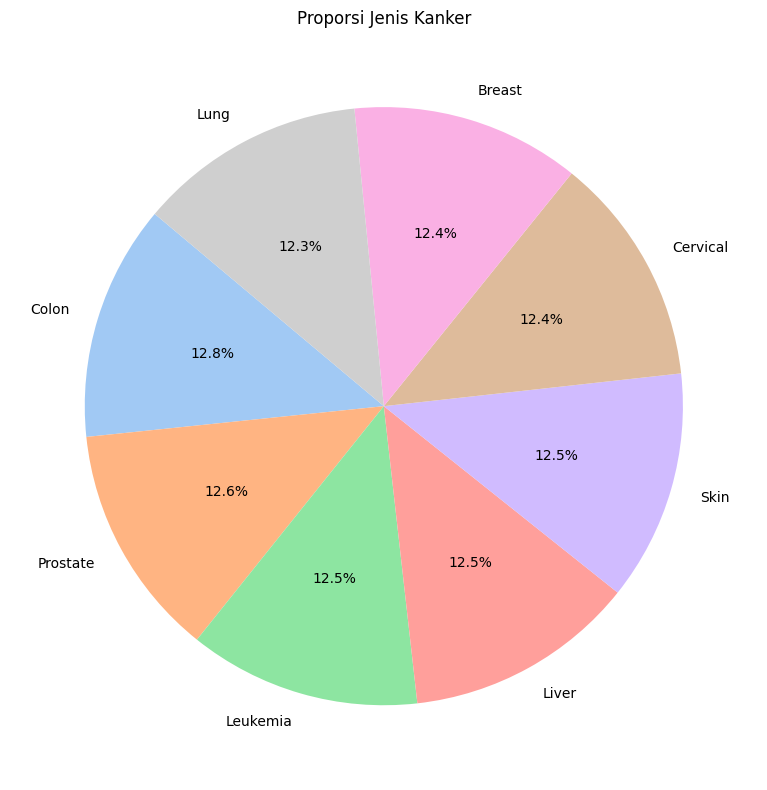

In [21]:
# Pie chart proporsi jenis kanker
if 'Cancer_Type' in df.columns:
    cancer_counts = df['Cancer_Type'].value_counts()

    plt.figure(figsize=(8, 8))
    plt.pie(cancer_counts, labels=cancer_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title('Proporsi Jenis Kanker')
    plt.tight_layout()
    plt.show()

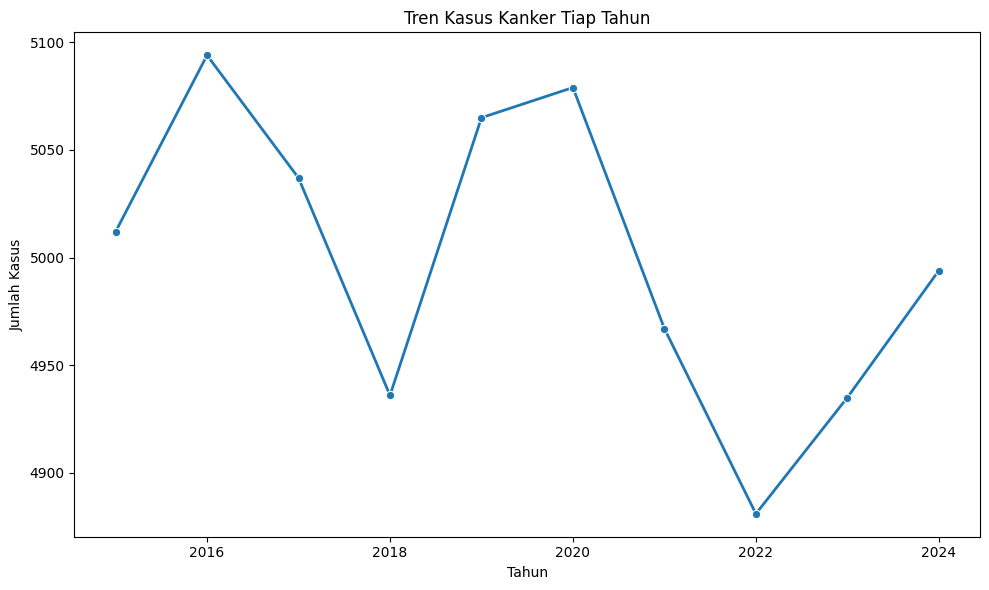

In [22]:
# Trends Over Time (Line Plot)
if 'Year' in df.columns:
    df_counts = df.groupby('Year').size().reset_index(name='Count')

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_counts, x='Year', y='Count', marker='o', linewidth=2)
    plt.title('Tren Kasus Kanker Tiap Tahun')
    plt.xlabel('Tahun')
    plt.ylabel('Jumlah Kasus')
    plt.tight_layout()
    plt.show()

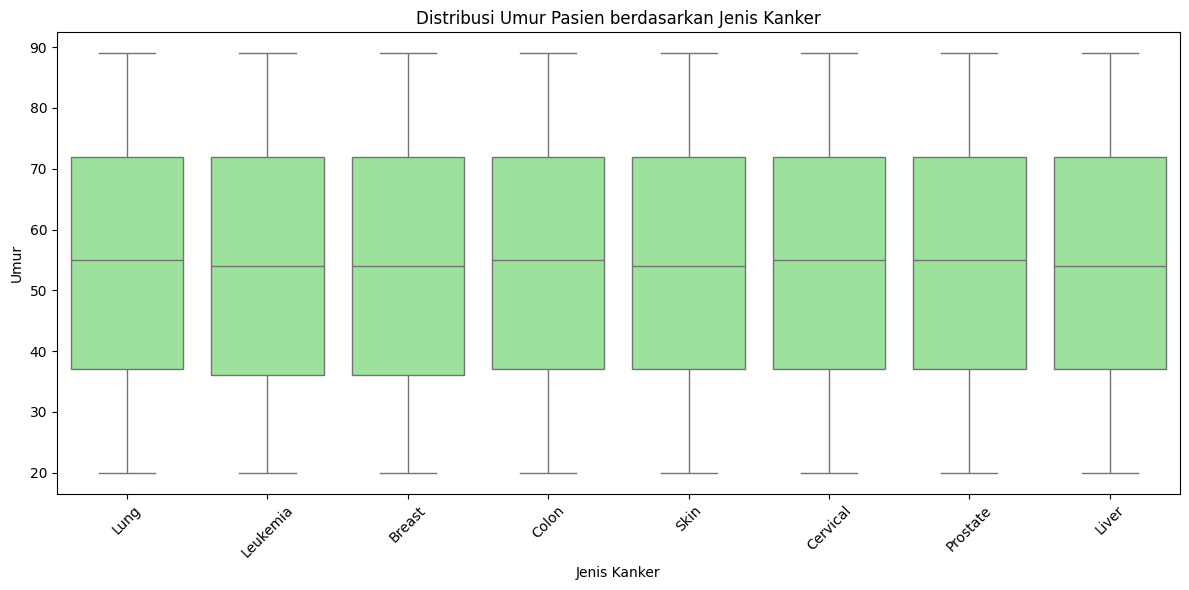

In [23]:
# Boxplot Umur per Jenis Kanker
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Cancer_Type', y='Age', color='lightgreen')
plt.xticks(rotation=45)
plt.title('Distribusi Umur Pasien berdasarkan Jenis Kanker')
plt.xlabel('Jenis Kanker')
plt.ylabel('Umur')
plt.tight_layout()
plt.show()

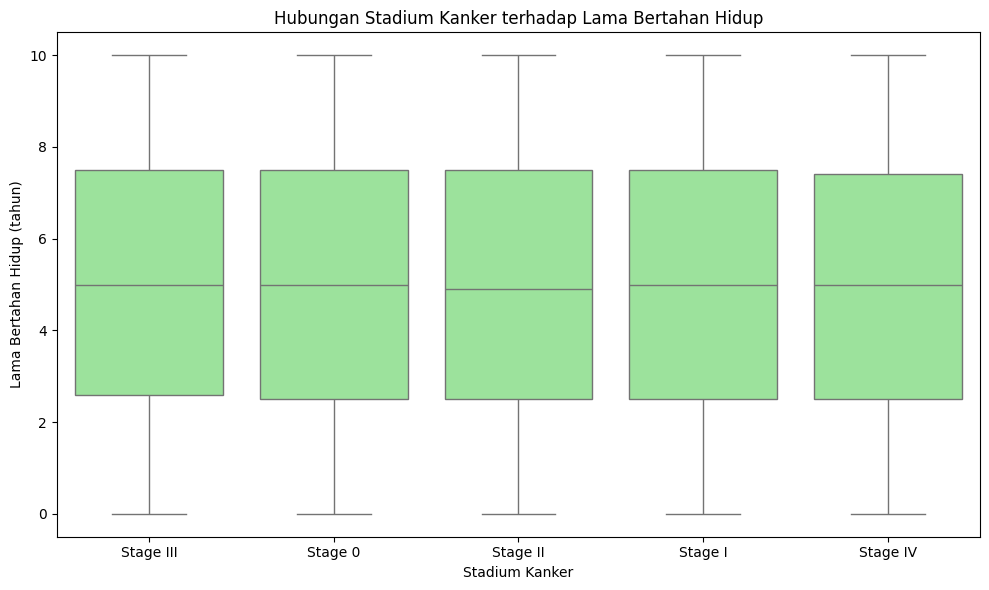

In [24]:
# Boxplot Survival berdasarkan Stadium Kanker
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Cancer_Stage', y='Survival_Years', color='lightgreen')
plt.title('Hubungan Stadium Kanker terhadap Lama Bertahan Hidup')
plt.xlabel('Stadium Kanker')
plt.ylabel('Lama Bertahan Hidup (tahun)')
plt.tight_layout()
plt.show()

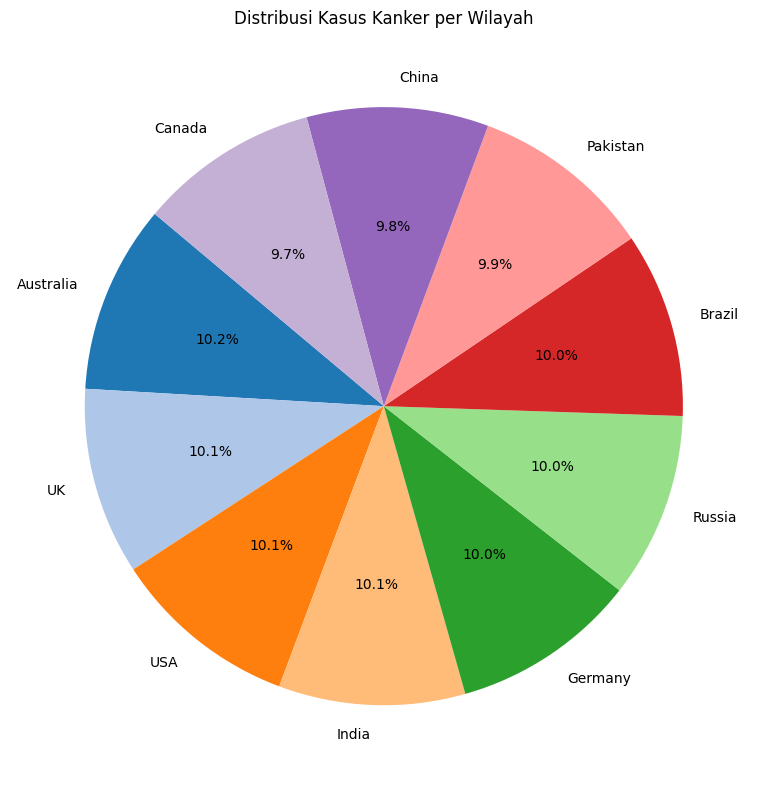

In [25]:
# Pie Chart Proporsi Kasus per Wilayah
if 'Country_Region' in df.columns:
    country_counts = df['Country_Region'].value_counts()

    plt.figure(figsize=(10, 8))
    plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('tab20'))
    plt.title('Distribusi Kasus Kanker per Wilayah')
    plt.tight_layout()
    plt.show()

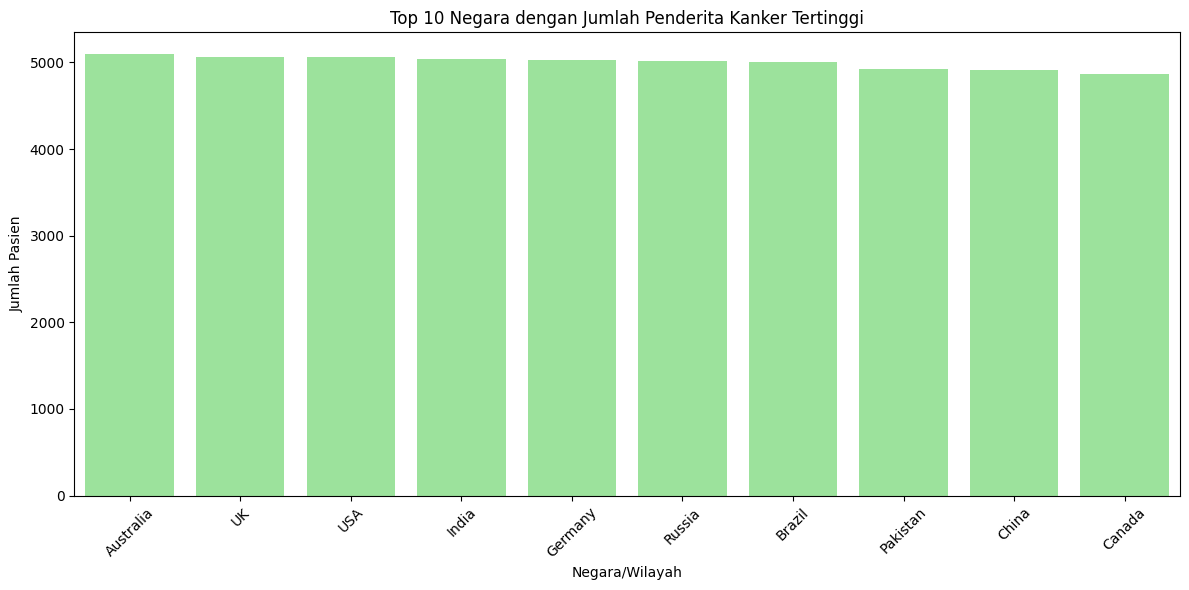

In [30]:
# Jumlah pasien per negara/wilayah
country_counts = df['Country_Region'].value_counts()

# Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index[:10], y=country_counts.values[:10], color='lightgreen')
plt.xticks(rotation=45)
plt.title('Top 10 Negara dengan Jumlah Penderita Kanker Tertinggi')
plt.ylabel('Jumlah Pasien')
plt.xlabel('Negara/Wilayah')
plt.tight_layout()
plt.show()

In [31]:
# Gabungkan statistik rata-rata faktor risiko per negara
faktor_risiko = df.groupby('Country_Region')[['Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']].mean().sort_values(by='Air_Pollution', ascending=False)

# Tampilkan top 10 negara berdasarkan faktor risiko tertentu
print(faktor_risiko.head(10))

                Air_Pollution  Alcohol_Use   Smoking  Obesity_Level
Country_Region                                                     
China                5.058600     4.986403  4.952697       5.007043
UK                   5.053360     5.053814  4.953696       4.964091
India                5.042758     4.976964  4.966468       5.013115
Australia            5.030754     5.006088  4.972310       4.965711
Pakistan             5.015895     4.922391  4.935749       5.063459
Brazil               5.002338     5.015528  4.989808       4.943845
Russia               4.986625     5.100299  5.016205       4.957465
Canada               4.982340     4.984334  4.990296       5.021711
Germany              4.980573     5.031031  5.022074       4.993989
USA                  4.948004     5.028715  5.096937       4.984348


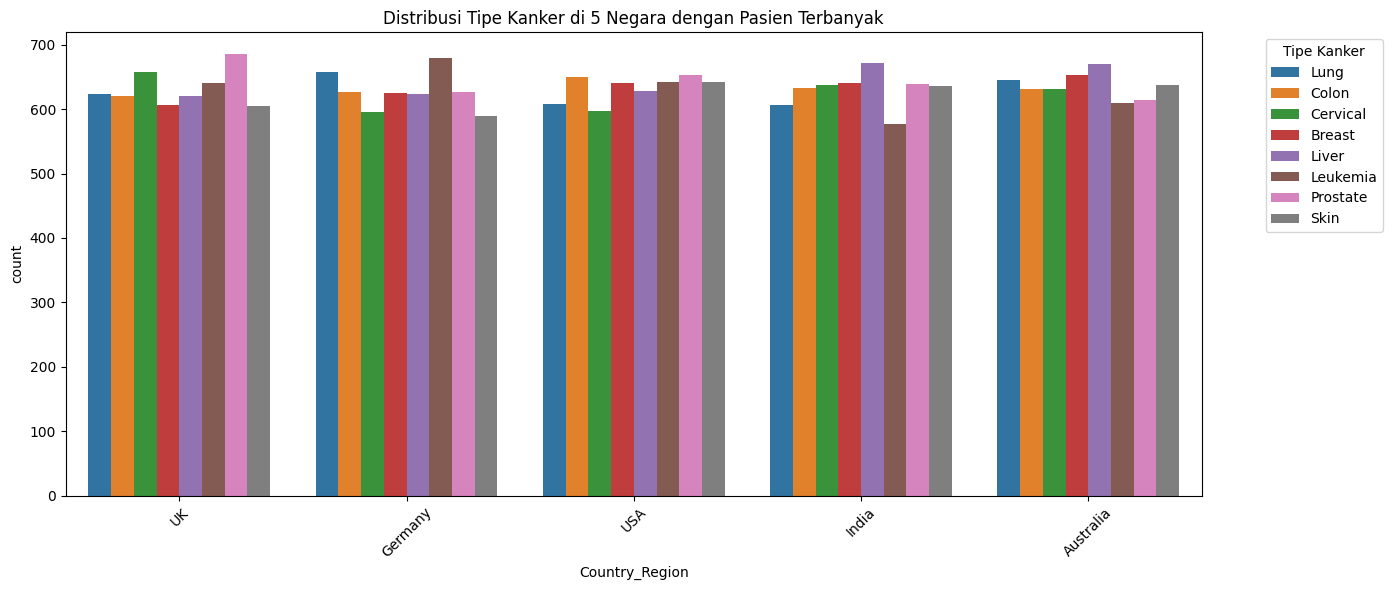

In [46]:
# Jenis kanker di 5 negara penderita terbanyak
top_countries = df['Country_Region'].value_counts().head(5).index
filtered_df = df[df['Country_Region'].isin(top_countries)]

plt.figure(figsize=(14, 6))
sns.countplot(data=filtered_df, x='Country_Region', hue='Cancer_Type')
plt.title('Distribusi Tipe Kanker di 5 Negara dengan Pasien Terbanyak')
plt.xticks(rotation=45)
plt.legend(title='Tipe Kanker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

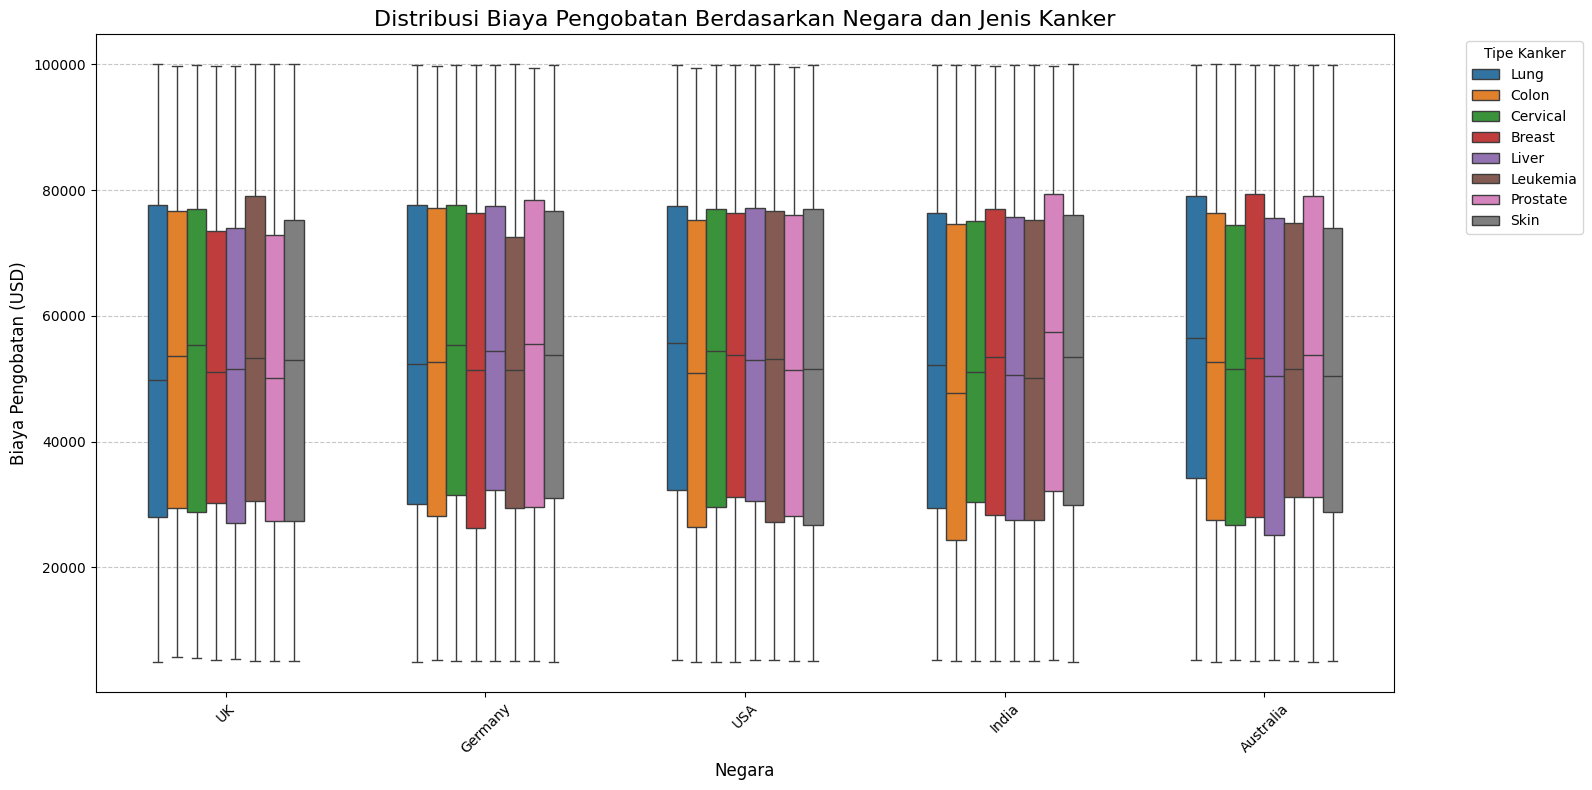

In [47]:
# Biaya pengobatan berdasarkan jenis dan negara
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=filtered_df,
    x='Country_Region',
    y='Treatment_Cost_USD',
    hue='Cancer_Type',
    width=0.6,
    dodge=True,           # Pisahkan antar cancer type
    fliersize=2,          # Kecilkan titik outlier
    linewidth=1
)
plt.title('Distribusi Biaya Pengobatan Berdasarkan Negara dan Jenis Kanker', fontsize=16)
plt.xlabel('Negara', fontsize=12)
plt.ylabel('Biaya Pengobatan (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Tipe Kanker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


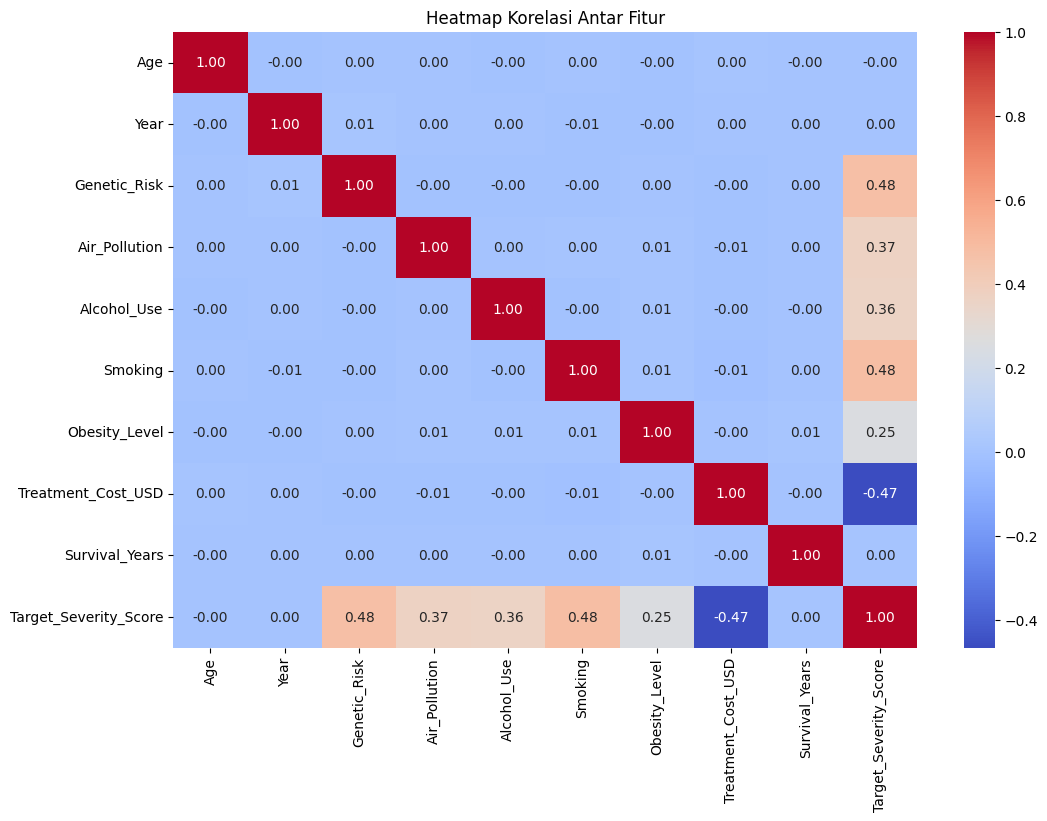

In [41]:
# Filter hanya kolom numerik
numeric_columns = df.select_dtypes(include=[np.number])

# Korelasi antar Fitur
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

# Data Preparation

In [42]:
# Buat DataFrame baru df ke new_df
new_df = df.copy()

# Konversi Target_Severity_Score menjadi kelas
def convert_to_class(value):
    if value < 4:
        return 'Rendah'
    elif value < 7:
        return 'Sedang'
    else:
        return 'Tinggi'

# Add the 'Severity_Class' column for classification
new_df['Severity_Class'] = new_df['Target_Severity_Score'].apply(convert_to_class)

# Fitur numerik dan kategorik
features = ['Age', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Treatment_Cost_USD']
categorical_features = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']

X = new_df[features + categorical_features]
y = new_df['Severity_Class']

# Encode the target variable to numeric labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split with the encoded target variable
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Column transformer untuk encoding
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Transform data (encoding and scaling)
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Scale the data
scaler = StandardScaler()
X_train_encoded_scaled = scaler.fit_transform(X_train_encoded)
X_test_encoded_scaled = scaler.transform(X_test_encoded)


Train Results:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.998475   0.998475 0.998475  0.998472
      Decision Tree  1.000000   1.000000 1.000000  1.000000
      Random Forest  1.000000   1.000000 1.000000  1.000000
        Naive Bayes  0.865400   0.886203 0.865400  0.845862
            XGBoost  1.000000   1.000000 1.000000  1.000000

Test Results: 
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9966   0.996593  0.9966  0.996593
      Decision Tree    0.8958   0.895887  0.8958  0.895830
      Random Forest    0.9158   0.922731  0.9158  0.906566
        Naive Bayes    0.8627   0.884304  0.8627  0.842026
            XGBoost    0.9733   0.973179  0.9733  0.972993




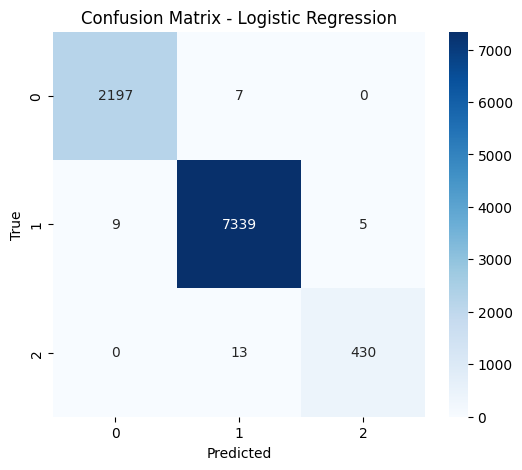

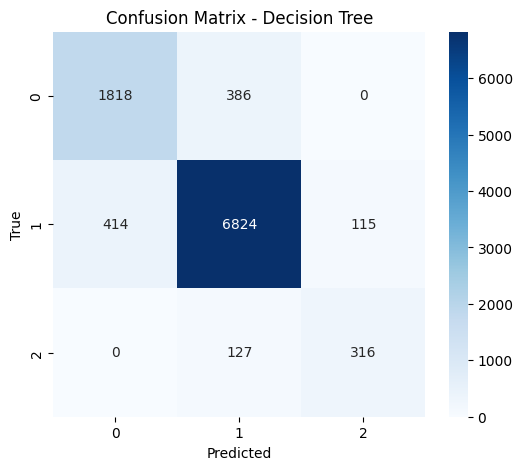

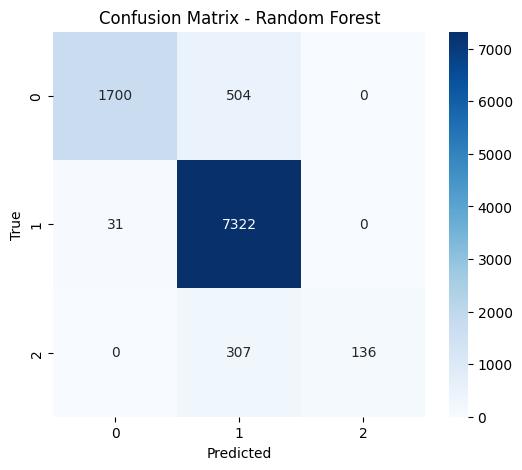

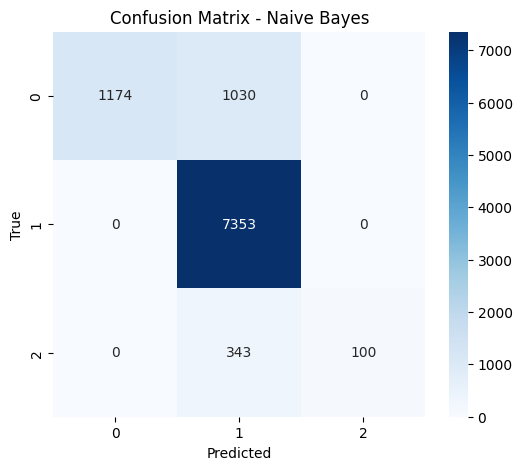

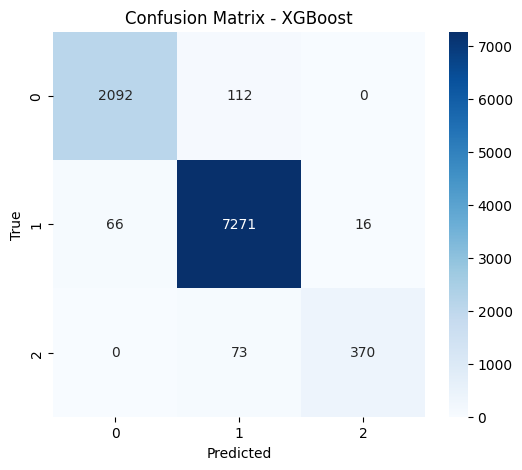

In [43]:
# Model dictionary
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': xgb.XGBClassifier()
}

# Evaluation function
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    return {
        'Confusion Matrix': cm,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    }

# Train & evaluate
results_train = {}
results_test = {}

# Train models
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_encoded_scaled, y_train)
    else:
        model.fit(X_train_encoded, y_train)

    results_train[name] = evaluate_model(model, X_train_encoded_scaled if name == 'Logistic Regression' else X_train_encoded, y_train)
    results_test[name] = evaluate_model(model, X_test_encoded_scaled if name == 'Logistic Regression' else X_test_encoded, y_test)

# Print train results
print('Train Results:')
train_df = pd.DataFrame([{'Model': name, **results_train[name]} for name in results_train])
print(train_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

# Print test results
print('\nTest Results: ')
test_df = pd.DataFrame([{'Model': name, **results_test[name]} for name in results_test])
print(test_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))

print('\n ================================================================= \n')

# Visualize confusion matrix for each model
for name, model in models.items():
    y_pred = model.predict(X_test_encoded_scaled if name == 'Logistic Regression' else X_test_encoded)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


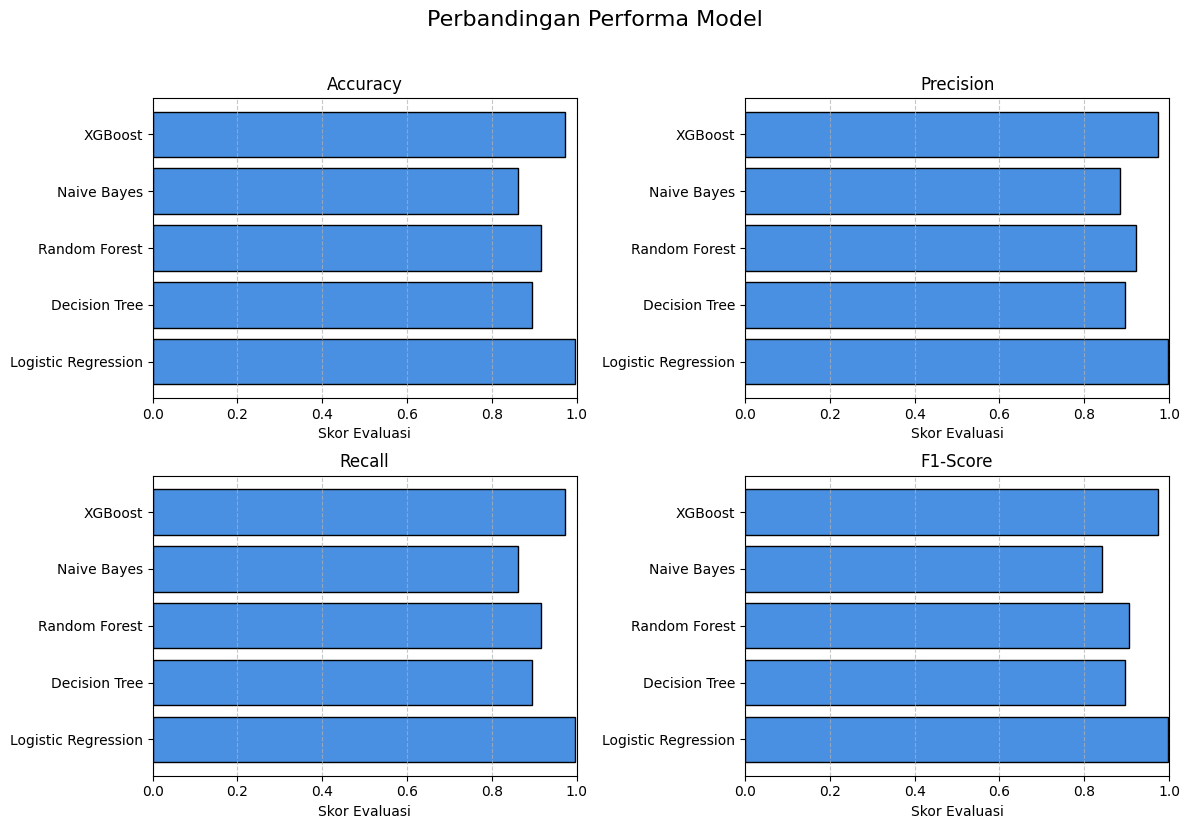

In [44]:
# Salin hasil test ke results_df untuk visualisasi
new_df = pd.DataFrame([{'Model': name, **results_test[name]} for name in results_test])
results_df = new_df.copy()

# Metode evaluasi
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Ukuran canvas
plt.figure(figsize=(12, 8))

# Loop untuk masing-masing metrik
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    plt.barh(results_df['Model'], results_df[metric], color='#4A90E2', edgecolor='black')
    plt.title(metric)
    plt.xlim(0, 1)
    plt.xlabel('Skor Evaluasi')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

# Supaya tampilan rapi
plt.tight_layout()
plt.suptitle('Perbandingan Performa Model', fontsize=16, y=1.03)
plt.subplots_adjust(top=0.92)
plt.show()

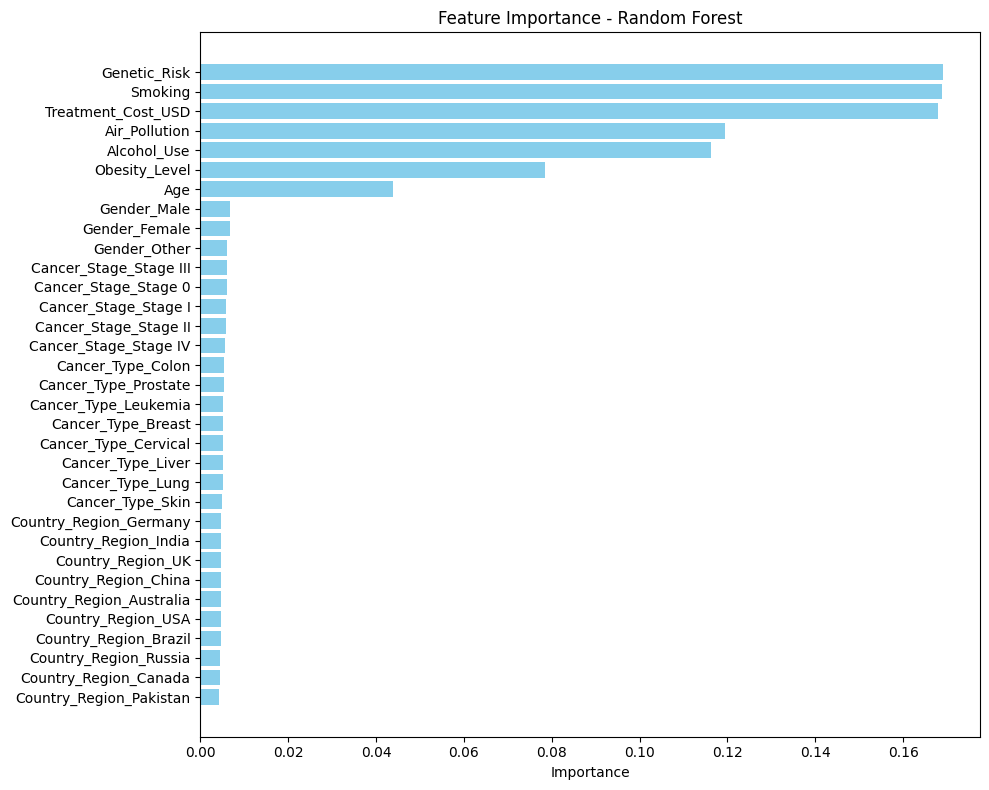

In [45]:
# Ambil model Random Forest yang sudah dilatih
rf_model = models['Random Forest']

# Ambil nama fitur numerik dan hasil one-hot dari fitur kategorik
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = features + cat_feature_names

# Ambil feature importance
importances = rf_model.feature_importances_

# Buat DataFrame untuk visualisasi
feat_importances = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Visualisasikan
plt.figure(figsize=(10, 8))
plt.barh(feat_importances['Feature'], feat_importances['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()


# Evaluasi

# Hasil Analisis :
1. Model dengan Performa Terbaik di Train Data:
  - Decision Tree, Random Forest, dan XGBoost memiliki Accuracy, Precision, Recall, dan F1-Score yang sempurna (1.0000) pada train dataset. Model-model ini memberikan hasil yang sangat baik dalam hal prediksi kelas, menunjukkan bahwa mereka dapat sepenuhnya menghafal data latih.
  - Logistic Regression juga menunjukkan hasil yang sangat baik dengan Accuracy dan F1-Score yang hampir sempurna.

2. Model dengan Performa Terbaik di Test Data:
  - XGBoost adalah yang terbaik pada test data dengan Accuracy sebesar 0.9733 dan F1-Score sebesar 0.9730, menunjukkan performa yang sangat baik saat diuji pada data yang belum pernah dilihat sebelumnya.
  - Logistic Regression juga memberikan hasil yang sangat bagus pada test set, dengan Accuracy 0.9966 dan F1-Score 0.9966.
  - Decision Tree dan Random Forest menunjukkan sedikit penurunan performa dibandingkan dengan train data, namun tetap memiliki kinerja yang solid di test data.
  - Naive Bayes menunjukkan penurunan performa yang signifikan pada test data dengan Accuracy hanya 0.8627, jauh lebih rendah dibandingkan model lainnya.

# Kesimpulan:
1. XGBoost dan Logistic Regression merupakan dua model dengan performa paling stabil, memberikan hasil yang sangat baik pada kedua data (train dan test).
2. Random Forest dan Decision Tree juga memberikan hasil yang baik, namun ada sedikit penurunan pada test data, menunjukkan kemungkinan adanya overfitting pada train data.
3. Naive Bayes tampaknya tidak memberikan hasil yang baik pada dataset ini, terutama pada test data, yang menunjukkan bahwa model ini kurang efektif untuk data yang lebih kompleks.